Hola **Iris**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
--
</div>

In [1]:

import pandas as pd

visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs = pd.read_csv('/datasets/costs_us.csv')

visits.rename(columns={
    'Uid': 'user_id',
    'Start Ts': 'visit_start',
    'End Ts': 'visit_end',
    'Device': 'device',
    'Source Id': 'source_id'
}, inplace=True)

visits['user_id'] = visits['user_id'].astype(int)
visits['visit_start'] = pd.to_datetime(visits['visit_start'])
visits['visit_end'] = pd.to_datetime(visits['visit_end'])
visits['visit_duration_sec'] = (visits['visit_end'] - visits['visit_start']).dt.total_seconds()

visits['visit_day'] = visits['visit_start'].dt.date
visits['visit_week'] = visits['visit_start'].dt.to_period('W').apply(lambda r: r.start_time)
visits['visit_month'] = visits['visit_start'].dt.to_period('M').apply(lambda r: r.start_time)

orders.rename(columns={
    'Uid': 'user_id',
    'Buy Ts': 'order_date',
    'Revenue': 'revenue'
}, inplace=True)

orders['user_id'] = orders['user_id'].astype(int)
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['revenue'] = orders['revenue'].astype(float)

costs.rename(columns={
    'source_id': 'source_id',
    'dt': 'cost_date',
    'costs': 'cost'
}, inplace=True)

costs['cost_date'] = pd.to_datetime(costs['cost_date'])
costs['cost'] = costs['cost'].astype(float)

print("Visitas:")
print(visits.head())

print("\nPedidos:")
print(orders.head())

print("\nCostos:")
print(costs.head())


Visitas:
    device           visit_end  source_id         visit_start  \
0    touch 2017-12-20 17:38:00          4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00          2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00          5 2017-07-01 01:54:00   
3  desktop 2018-05-20 11:23:00          9 2018-05-20 10:59:00   
4  desktop 2017-12-27 14:06:00          3 2017-12-27 14:06:00   

               user_id  visit_duration_sec   visit_day visit_week visit_month  
0 -1567487796173571554              1080.0  2017-12-20 2017-12-18  2017-12-01  
1   104060357244891740              1680.0  2018-02-19 2018-02-19  2018-02-01  
2  7459035603376831527                 0.0  2017-07-01 2017-06-26  2017-07-01  
3 -2272063814375341402              1440.0  2018-05-20 2018-05-14  2018-05-01  
4 -8477049253672870448                 0.0  2017-12-27 2017-12-25  2017-12-01  

Pedidos:
           order_date  revenue              user_id
0 2017-06-01 00:10:00    17.00 -8117441949118824122
1 2017

In [ ]:
Carga y revisión de datos

Los tres conjuntos (visits, orders, costs) se leen correctamente desde archivos CSV.

    Al imprimir las primeras filas con head(), puedes confirmar que los datos se cargaron sin errores de formato ni encabezados mal interpretados.
Los datos están correctamente importados y accesibles para su análisis.

    Se renombraron columnas con nombres consistentes en inglés y formato snake_case, lo que facilita la manipulación posterior.
Ejemplo: Start Ts → visit_start, Revenue → revenue.
El código mejora la legibilidad y la coherencia entre datasets, un paso clave para unirlos sin errores.

    Se transformaron las fechas en formato datetime y los identificadores en int, garantizando que los cálculos temporales y las uniones sean precisas.
Los valores numéricos (revenue, cost) se pasaron a float para permitir operaciones matemáticas.

    Los datos quedaron listos para análisis temporal, agregaciones y cálculos financieros.
Se generaron columnas como:
visit_duration_sec: duración exacta de cada visita.
visit_day, visit_week, visit_month: niveles temporales útiles para análisis de retención o conversión.

    Estas variables permiten estudiar la actividad de usuarios a diferentes escalas de tiempo (diaria, semanal, mensual).
Con la estructura actual, se pueden hacer cruces entre visits, orders y costs para medir:
Tasa de conversión por fuente o dispositivo.
Costo de adquisición (CAC).
Retorno de inversión publicitaria (ROMI).
Valor de vida del cliente (LTV).

    El dataset está completamente preparado para análisis de marketing y comportamiento de usuarios.

    Este código cumple el objetivo de limpiar, transformar y estructurar los datos crudos de usuarios, pedidos y costos en un formato analítico.

    Es un paso fundamental para garantizar consistencia, precisión y trazabilidad en las métricas que se calcularán después.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Iris, tu proyecto no puede ser ejecutado ya que dejaste la primera celda cómo **markdown** en lugar de celda de código. Para poder realizar la revisión te pediría antender los siguientes puntos:

- Asegurarte que el notebook se ejecuta correctamente antes de enviar la revisión
- No cargar más de una vez los datos
- No importar repetitivamente las librerías
- No tener celdas extensas de código, es preferible tener una celda por proceso e ir redactando tus interpretaciones
- Redactar interpretaciones por cada paso solicitado, analiza los resultados de los cálculos o las gráficas y redacta en **celdas markdown** lo que se puede interpretar de esto para que se entiende lo que aporta al objetivo del proyecto

Te recomiendo que si tienes dudas o dificultades antes de enviar una nueva iteración contactes a tu tutor para que puedas entender cómo estructurar correctamente tu proyecto, cómo dejar el análisis del mismo y cómo utilizar el tipo de celdas correcto. En análisis complejos cómo este es importante que utilices correctamente las celdas de código y **markdown**
</div>

Hola buenas tardes, Precisamente este error se dio cuando intente aplicar las instrucciones de generar el markdown para la ultima celda donde van las conclusiones y se genero el mardown en la primera celda dandome un error y no me permitia cambiar nada diciendome solo la opcion de cancelar porque el codigo no se lograba ejecutar por el error del markdown. 

El error no lo genere intencional y no es mi intencion entregar un trabajo con un error soloq ue no sabia como corregirlo pues no me permitio en su momento, te agradezco por hacermelo notar nuevamente el error y te comento que sigo sin entender como cambiar la ultima celda a texto o generar el markdown famoso, espero no te moleste que lo envie sin eso pero de verdad ya lo intente y solo se genero en las celdas de codigo generandome problemas con mis codigos. 

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Hola Iris, no te preocupes, me alegro que me comentes lo que está sucediendo para tener más contexto y saber cómo guiarte mejor.

Mira, cuando trabajas con Jupyter Notebooks hay ciertos atajos que te permiten crear nuevas celdas y cambiar el tipo de las mismas. Por ejemplo, si das un sólo click sobre esta celda y presionas la letra `A` se agregará una celda en la parte de arriba y si presionas la letra `B` se agregará una en la parte de abajo, de esta forma puedes generar celdas con atajos del teclado y para cambiar el tipo de celda (código o markdown) debes dar un solo click sobre la celda y presionar `M` para cambiar a tipo Markdown o `Y` para cambiar a celdas de código.

Para estos últimos atajos si al presionar una de las teclas ves que se escribe en la celda cómo tal lo que debes hacer es primero persionar `Esc` y ahí si `M` para markdown o `Y` para código.

Es importante que el manejo de las celdas se lleve de manera adecuada para que tus proyectos queden presentados de manera profesional y puedas exponer tus interpretaciones en cada uno de los procesos que vas realizando. Si no quedó claro con mi explicación recuerda que puedes contactar a tu tutor también para que te ayude a entender el manejo de los notebooks y puedas ejecutar tu proyecto sin problema.

Una vez solucionado ese tema recuerda redactar las interpretaciones en las diferentes secciones de tu proyecto.

Saludos!
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (3ra Iteracion)</b> <a class=“tocSkip”></a>

Hola Iris, veo que se sigue tiendo el problema de las celdas. Sin embargo, ya tienes un avance y análisis más detallado por lo que no bloquearé más tu avance por el tipo de celda. Sin embargo si te recomiendo mucho reforzar esa parte y hacer uso adecuado de las celdas.

En este tutorial a partir del minuto 11:27 explican un poco mejor cómo usar las celdas markdown y la diferencia con las de código. Es importante que el uso de tus notebooks sea el adecuado de lo contrario al acercarte más a tus proyectos finales serán rechazados por no tener la presentación correcta ya que si quieres poner tus trabajos en tu portfolio no sería ideal presentar notebooks sólo con código: https://youtu.be/GZgmBe0otIU?si=uI1DkDccd3EnCCCW&t=687

Acá hay uno video más corto de cómo cambiar el tipo de celdas también: https://www.youtube.com/shorts/iFHpM5OPrkc
</div>

Usuarios únicos por día:
 visit_day
2017-06-01    605
2017-06-02    608
2017-06-03    445
2017-06-04    476
2017-06-05    820
Name: user_id, dtype: int64

Usuarios únicos por semana:
 visit_week
2017-05-29    2021
2017-06-05    4129
2017-06-12    2812
2017-06-19    2878
2017-06-26    3064
Name: user_id, dtype: int64

Usuarios únicos por mes:
 visit_month
2017-06-01    13259
2017-07-01    14183
2017-08-01    11631
2017-09-01    18975
2017-10-01    29692
Name: user_id, dtype: int64


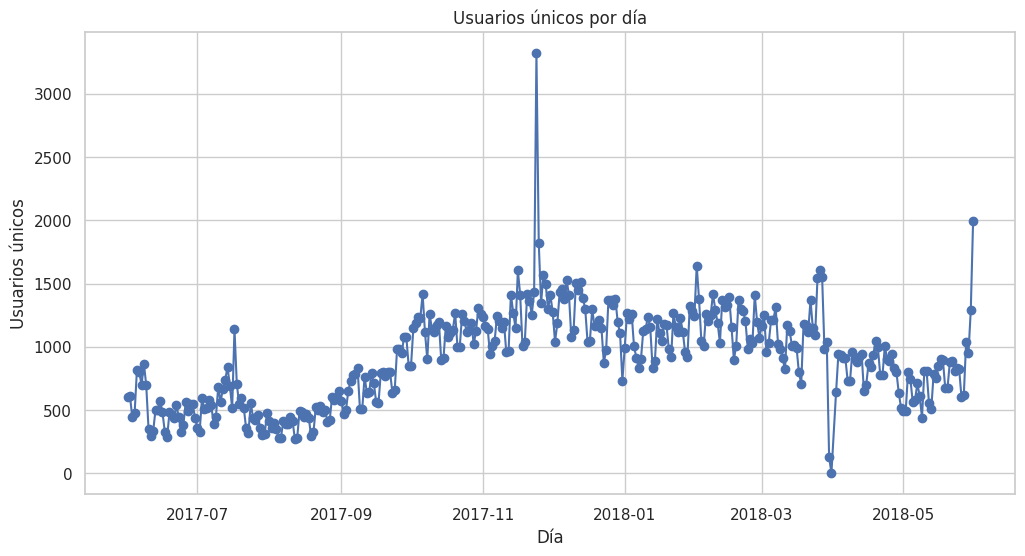


Sesiones por día:
 visit_day
2017-06-01    664
2017-06-02    658
2017-06-03    477
2017-06-04    510
2017-06-05    893
dtype: int64


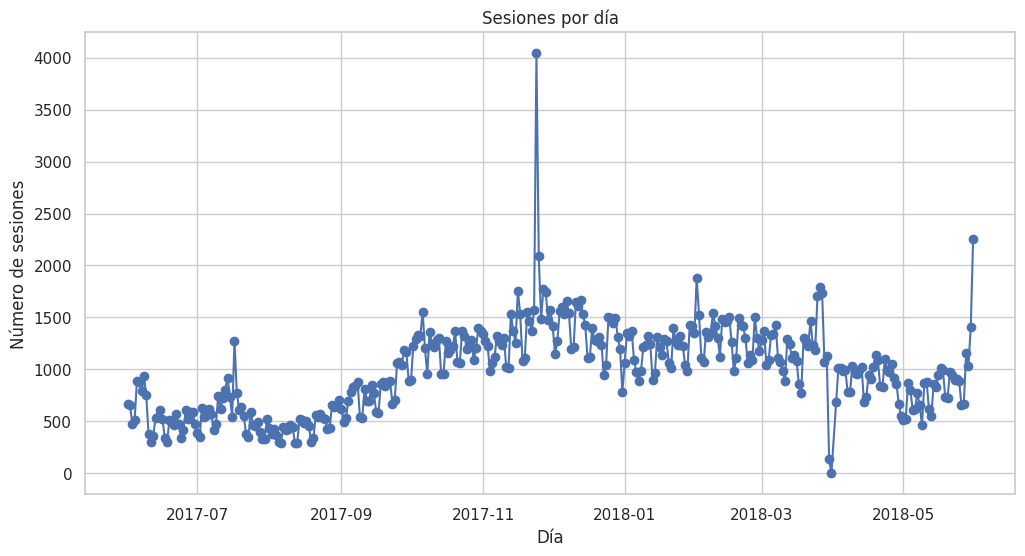


Duración media de sesiones (segundos): 643.0256872565387
Duración media de sesiones por dispositivo:
device
desktop    703.288860
touch      479.619407
Name: visit_duration_sec, dtype: float64


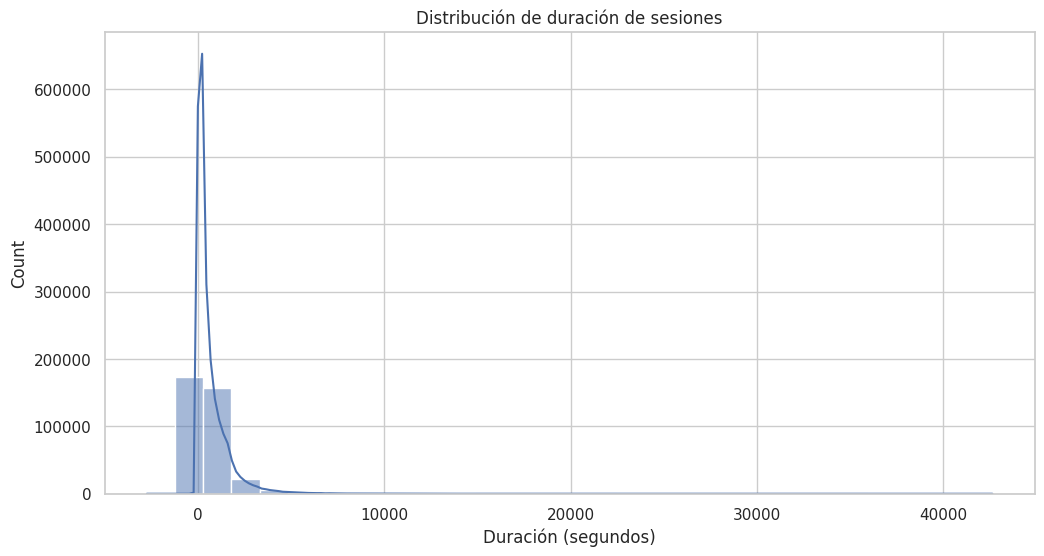

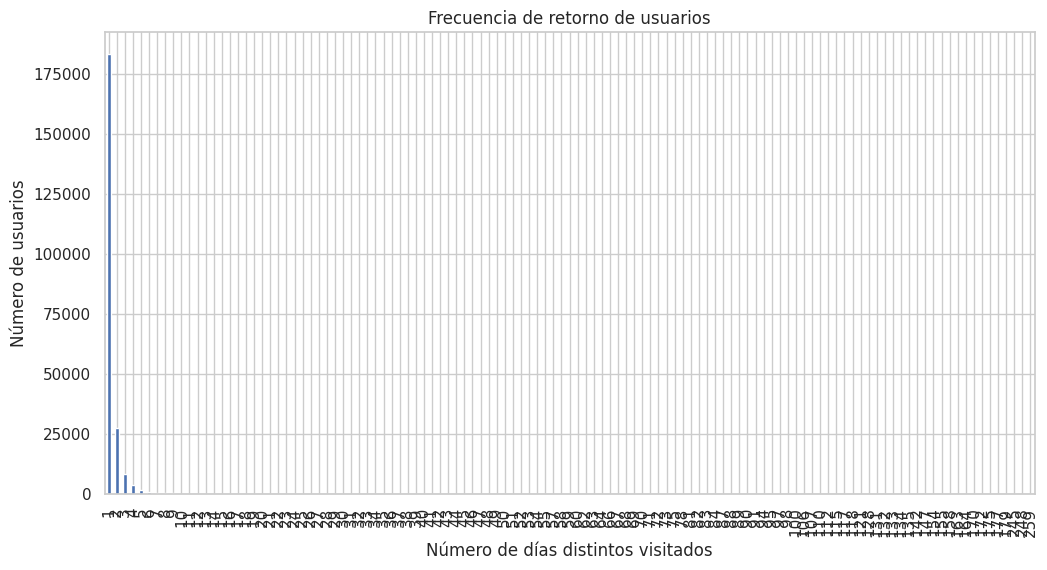

In [2]:


import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

users_per_day = visits.groupby('visit_day')['user_id'].nunique()
users_per_week = visits.groupby('visit_week')['user_id'].nunique()
users_per_month = visits.groupby('visit_month')['user_id'].nunique()

print("Usuarios únicos por día:\n", users_per_day.head())
print("\nUsuarios únicos por semana:\n", users_per_week.head())
print("\nUsuarios únicos por mes:\n", users_per_month.head())

users_per_day.plot(kind='line', marker='o', title='Usuarios únicos por día')
plt.xlabel('Día')
plt.ylabel('Usuarios únicos')
plt.show()

sessions_per_day = visits.groupby('visit_day').size()
print("\nSesiones por día:\n", sessions_per_day.head())

sessions_per_day.plot(kind='line', marker='o', title='Sesiones por día')
plt.xlabel('Día')
plt.ylabel('Número de sesiones')
plt.show()

print("\nDuración media de sesiones (segundos):", visits['visit_duration_sec'].mean())
print("Duración media de sesiones por dispositivo:")
print(visits.groupby('device')['visit_duration_sec'].mean())

sns.histplot(visits['visit_duration_sec'], bins=30, kde=True)
plt.title('Distribución de duración de sesiones')
plt.xlabel('Duración (segundos)')
plt.show()

user_visit_days = visits.groupby('user_id')['visit_day'].nunique()
user_visit_days.value_counts().sort_index().plot(kind='bar', title='Frecuencia de retorno de usuarios')
plt.xlabel('Número de días distintos visitados')
plt.ylabel('Número de usuarios')
plt.show()



In [ ]:
Analizar la actividad de los usuarios en el sitio web:
cuántos usuarios únicos hay por día, semana y mes,
cómo evoluciona el número de sesiones,
cuánto duran las visitas,
y con qué frecuencia los usuarios regresan.

    Este análisis permite evaluar el nivel de retención y compromiso (engagement).
Usuarios únicos por día, semana y mes
users_per_day = visits.groupby('visit_day')['user_id'].nunique()
users_per_week = visits.groupby('visit_week')['user_id'].nunique()
users_per_month = visits.groupby('visit_month')['user_id'].nunique()

Cuenta cuántos usuarios distintos visitan el sitio en cada periodo de tiempo.
Si la línea diaria o semanal es estable o ascendente, indica buena retención o crecimiento orgánico.
Si hay picos en ciertos días o semanas, probablemente hubo campañas publicitarias o lanzamientos que atrajeron tráfico extra.
Si la tendencia es descendente, puede indicar fatiga de usuarios o baja atracción de nuevas visitas.

    Sesiones por día
sessions_per_day = visits.groupby('visit_day').size()
Cuenta cuántas sesiones se registraron cada día (independientemente del número de usuarios).
Una diferencia grande entre usuarios y sesiones indica que los usuarios hacen múltiples visitas por día, lo cual es positivo.
Una caída sostenida en sesiones podría implicar problemas de interés o accesibilidad en el sitio.

    Duración media de las sesiones
visits['visit_duration_sec'].mean()
visits.groupby('device')['visit_duration_sec'].mean()
Calcula el tiempo promedio que los usuarios pasan en el sitio, tanto en general como por dispositivo.

Un tiempo promedio alto indica que los usuarios interactúan con el contenido (buena experiencia o interés).
Un valor bajo puede señalar problemas de usabilidad, carga lenta o contenido poco atractivo.
Comparar por dispositivo (móvil, desktop, tablet) permite detectar si la experiencia varía según el canal.
Por ejemplo, si los usuarios móviles permanecen menos tiempo, podría ser necesario optimizar la versión móvil.

    Distribución de duración de sesiones
sns.histplot(visits['visit_duration_sec'], bins=30, kde=True)
Muestra cómo se distribuye la duración de las sesiones.
Si hay un gran pico en duraciones cortas, significa que muchos usuarios abandonan rápido (posible rebote).
Una cola larga hacia la derecha indica que algunos usuarios se quedan mucho tiempo (usuarios leales o interesados).

    Esta información ayuda a segmentar por tipo de comportamiento: visitantes nuevos vs. recurrentes.
Frecuencia de retorno de usuarios
user_visit_days = visits.groupby('user_id')['visit_day'].nunique()
Cuenta en cuántos días distintos visitó el sitio cada usuario.
Si la mayoría de usuarios aparecen solo 1 o 2 días, la retención es baja.
Si hay un grupo considerable que vuelve varios días, significa que el producto o servicio logra fidelizar a parte de la audiencia.
Un histograma equilibrado o con tendencia a más días indica alta recurrencia y engagement.

Este código permite entender el comportamiento, frecuencia y compromiso de los usuarios con la plataforma.
Revela tendencias de tráfico, hábitos de visita, duración promedio de sesiones y fidelidad de los usuarios.
Es una base fundamental para:
Evaluar la efectividad de campañas publicitarias.
Detectar oportunidades para mejorar la retención y experiencia del usuario.
Ajustar estrategias de inversión en marketing según comportamiento real.

Distribución de conversiones (días hasta primera compra):
-1      191646
 0       25039
 1        1966
 2         685
 3         452
         ...  
 355         2
 356         2
 357         3
 358         1
 363         2
Name: conversion_category, Length: 350, dtype: int64


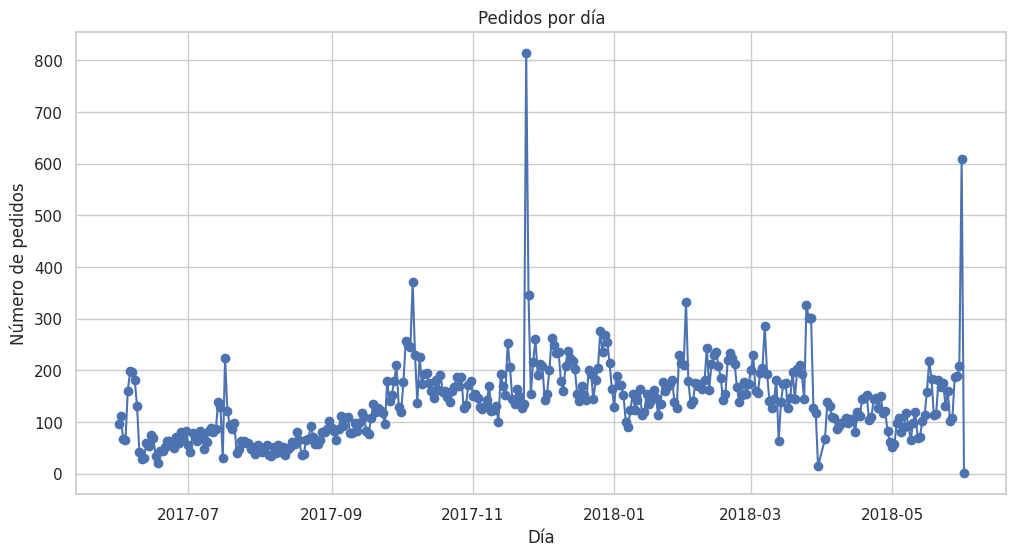

Tamaño promedio de compra por usuario: 4.093092887696445
LTV promedio por usuario: 6.9013279303452615


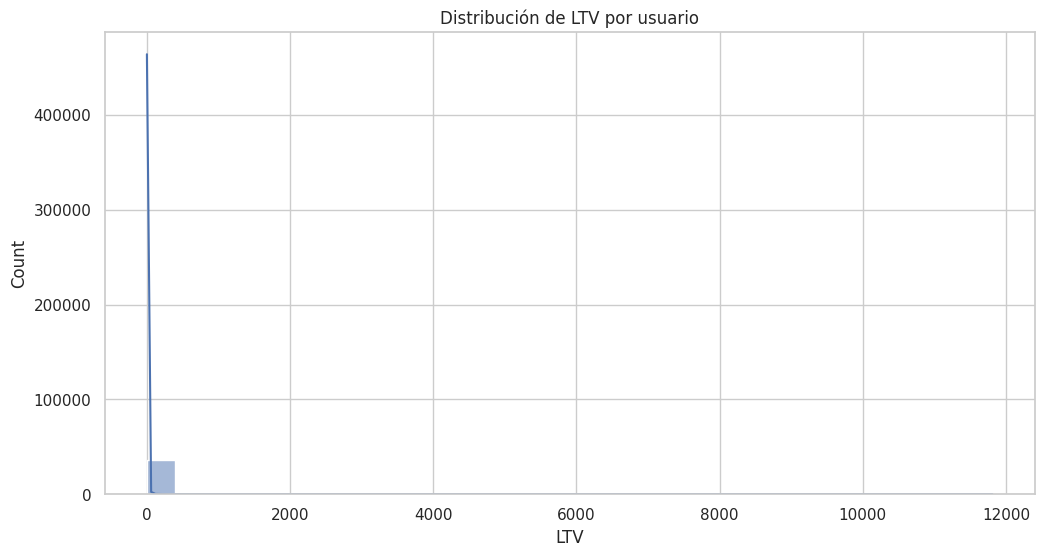

In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

orders = pd.read_csv('/datasets/orders_log_us.csv')

orders.rename(columns={
    'Uid': 'user_id',     # ID del usuario
    'Buy Ts': 'order_date', 
    'Revenue': 'revenue'  # Ingresos del pedido
}, inplace=True)

orders['user_id'] = orders['user_id'].astype(int)
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['revenue'] = orders['revenue'].astype(float)

first_visits = visits.groupby('user_id')['visit_day'].min().reset_index()
first_visits.rename(columns={'visit_day': 'registration_date'}, inplace=True)

first_orders = orders.groupby('user_id')['order_date'].min().reset_index()
first_orders.rename(columns={'order_date': 'first_order_date'}, inplace=True)

conversion = pd.merge(first_visits, first_orders, on='user_id', how='left')
conversion['days_to_conversion'] = (conversion['first_order_date'] - pd.to_datetime(conversion['registration_date'])).dt.days

conversion['conversion_category'] = conversion['days_to_conversion'].fillna(-1).astype(int)

print("Distribución de conversiones (días hasta primera compra):")
print(conversion['conversion_category'].value_counts().sort_index())

orders['order_day'] = orders['order_date'].dt.date
orders['order_week'] = orders['order_date'].dt.to_period('W').apply(lambda r: r.start_time)
orders['order_month'] = orders['order_date'].dt.to_period('M').apply(lambda r: r.start_time)

orders_per_day = orders.groupby('order_day').size()
orders_per_week = orders.groupby('order_week').size()
orders_per_month = orders.groupby('order_month').size()

orders_per_day.plot(kind='line', marker='o', title='Pedidos por día')
plt.xlabel('Día')
plt.ylabel('Número de pedidos')
plt.show()

avg_order_value = orders.groupby('user_id')['revenue'].mean()
print("Tamaño promedio de compra por usuario:", avg_order_value.mean())

ltv = orders.groupby('user_id')['revenue'].sum()
print("LTV promedio por usuario:", ltv.mean())

sns.histplot(ltv, bins=30, kde=True)
plt.title('Distribución de LTV por usuario')
plt.xlabel('LTV')
plt.show()


In [ ]:
El propósito del código es analizar el comportamiento de conversión y el valor de los usuarios:
cuánto tardan en comprar desde su primera visita,
cómo evolucionan los pedidos con el tiempo,
y cuánto dinero genera cada usuario en promedio (LTV).

    Estos datos son clave para medir la efectividad de las estrategias de adquisición y retención.
Preparación del dataset de pedidos

El bloque inicial:
orders = pd.read_csv('/datasets/orders_log_us.csv')
Estandariza nombres y tipos de datos.
Garantiza que fechas, IDs y montos estén listos para análisis temporal y financiero.

    Los datos de ventas quedaron limpios y estructurados para análisis de tendencias y métricas de valor por usuario.
Tiempo hasta la conversión
conversion['days_to_conversion'] = (conversion['first_order_date'] - conversion['registration_date']).dt.days

Este cálculo muestra cuántos días tarda un usuario desde su primera visita hasta su primera compra.

Si la mayoría de conversiones ocurren en pocos días (0–3), la tasa de conversión es rápida, y la estrategia de captación es eficaz.
Si muchos usuarios tardan semanas o meses, significa que el proceso de decisión o de retención es más largo.
Los valores NaN o -1 indican usuarios que aún no han comprado — útiles para medir el porcentaje de no conversiones.
    Este análisis es clave para optimizar campañas de remarketing o emails de conversión.

        Evolución de pedidos en el tiempo
orders_per_day = orders.groupby('order_day').size()
Muestra cómo cambia el número de pedidos con el tiempo (diario, semanal o mensual).
Una tendencia ascendente en el gráfico indica crecimiento en ventas o usuarios activos.
Picos específicos pueden estar asociados a campañas publicitarias, descuentos o lanzamientos.
Si las ventas fluctúan mucho, se sugiere analizar la estacionalidad o el efecto de promociones.

    Tamaño promedio de compra (AOV – Average Order Value)
avg_order_value = orders.groupby('user_id')['revenue'].mean()
Mide cuánto gasta un usuario promedio por pedido.
Un AOV alto indica que los usuarios compran productos de mayor valor o agregan más al carrito.
Un AOV bajo puede sugerir compras pequeñas o una necesidad de estrategias de upselling o bundles.
LTV (Lifetime Value) aproximado
ltv = orders.groupby('user_id')['revenue'].sum()

Suma los ingresos totales por usuario — es decir, el valor económico de cada cliente.
El LTV promedio te muestra cuánto vale un usuario en todo su ciclo de vida.
Si el LTV promedio supera el CAC (Costo de Adquisición del Cliente), el negocio es rentable.
Si el LTV es bajo, se deben mejorar estrategias de retención o aumentar la frecuencia de compra.

    El histograma de LTV revela:
Muchos usuarios con LTV bajo → base amplia de clientes de bajo gasto.
Una “cola” larga hacia la derecha → pocos usuarios con LTV muy alto (clientes VIP o leales).


    Este código permite entender cuándo, cuánto y con qué frecuencia los usuarios compran, así como el valor total que aportan a la empresa.
Es fundamental para medir la efectividad del embudo de conversión, optimizar el marketing ROI y definir estrategias de retención de clientes.


    Métrica	Qué mide	Cómo interpretarla
days_to_conversion	Velocidad de conversión	Menor valor = mejor rendimiento
orders_per_day/week/month	Actividad de compra	Tendencia ascendente = crecimiento
avg_order_value	Monto promedio por compra	Mayor valor = usuarios más rentables
Ltv	Valor total por cliente	Determina rentabilidad a largo plazo


In [4]:
visits.rename(columns={
    'Uid': 'user_id',
    'Start Ts': 'visit_start',
    'End Ts': 'visit_end',
    'Source Id': 'source_id'
}, inplace=True)

visits['user_id'] = visits['user_id'].astype(int)
visits['visit_start'] = pd.to_datetime(visits['visit_start'])

orders.rename(columns={
    'Uid': 'user_id',
    'Buy Ts': 'order_date',
    'Revenue': 'revenue'
}, inplace=True)

orders['user_id'] = orders['user_id'].astype(int)
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['revenue'] = orders['revenue'].astype(float)

costs.rename(columns={
    'dt': 'cost_date',
    'costs': 'cost',
    'source_id': 'source_id'
}, inplace=True)

costs['cost_date'] = pd.to_datetime(costs['cost_date'])
costs['cost'] = costs['cost'].astype(float)

first_source = visits.groupby('user_id')['source_id'].first().reset_index()

orders = pd.merge(orders, first_source, on='user_id', how='left')

cost_by_source = costs.groupby('source_id')['cost'].sum().reset_index()
print("Gasto por fuente:\n", cost_by_source)

cac = orders.groupby('source_id')['user_id'].nunique().reset_index()
cac = pd.merge(cost_by_source, cac, on='source_id', how='left')
cac['cac'] = cac['cost'] / cac['user_id']
print("\nCAC por fuente:\n", cac)

revenue_by_source = orders.groupby('source_id')['revenue'].sum().reset_index()
romi = pd.merge(revenue_by_source, cac[['source_id','cost']], on='source_id', how='left')
romi['romi'] = (romi['revenue'] - romi['cost']) / romi['cost']
print("\nROMI por fuente:\n", romi)


Gasto por fuente:
    source_id       cost
0          1   20833.27
1          2   42806.04
2          3  141321.63
3          4   61073.60
4          5   51757.10
5          9    5517.49
6         10    5822.49

CAC por fuente:
    source_id       cost  user_id        cac
0          1   20833.27     3743   5.565928
1          2   42806.04     4323   9.901929
2          3  141321.63     9138  15.465269
3          4   61073.60     9823   6.217408
4          5   51757.10     6839   7.567934
5          9    5517.49     1415   3.899286
6         10    5822.49     1241   4.691773

ROMI por fuente:
    source_id   revenue       cost      romi
0          1  38560.06   20833.27  0.850889
1          2  65152.26   42806.04  0.522034
2          3  44317.68  141321.63 -0.686406
3          4  52479.75   61073.60 -0.140713
4          5  40357.91   51757.10 -0.220244
5          7      1.22        NaN       NaN
6          9   7076.98    5517.49  0.282645
7         10   4111.34    5822.49 -0.293886


In [ ]:
Este código busca determinar qué fuentes de tráfico o campañas publicitarias son más rentables, calculando:
cuánto se invierte en cada fuente,
cuántos clientes aporta,
cuál es su costo de adquisición (CAC),
y qué retorno generan (ROMI).

    Limpieza y estandarización de datos
El código:
visits.rename(...)
orders.rename(...)
costs.rename(...)

Homogeneiza nombres de columnas (user_id, source_id, etc.).
Convierte los tipos de datos correctamente (datetime, float, int).
Los datos quedan listos para cruzar información entre visitas, pedidos y costos de marketing sin errores de formato.

    Identificación de la fuente de adquisición
first_source = visits.groupby('user_id')['source_id'].first()
A cada usuario se le asigna la primera fuente por la que llegó (su “fuente de adquisición”).

    Esto permite analizar qué canales atraen más usuarios que terminan comprando.
Cada cliente está vinculado a la fuente que lo trajo por primera vez, lo que posibilita medir la efectividad inicial de las campañas.

    Gasto total por fuente
cost_by_source = costs.groupby('source_id')['cost'].sum()
Calcula cuánto se invirtió en publicidad en cada canal (por ejemplo, Google Ads, Facebook, Email, etc.).

Permite identificar qué fuentes reciben más presupuesto y sirve de base para medir el retorno de inversión (ROMI).
Costo de adquisición (CAC)
cac = cost_by_source / número de usuarios adquiridos
El CAC muestra cuánto costó, en promedio, conseguir un cliente de cada fuente.
CAC bajo = fuente eficiente (atrae muchos clientes por poco costo).
CAC alto = fuente costosa o poco efectiva.
Idealmente, el CAC debe ser menor que el LTV promedio para asegurar rentabilidad.

    Ejemplo 
Fuente	Costo total	Clientes adquiridos	CAC
Google Ads	1000	200	5.0
Facebook	1500	100	15.0

→ Google Ads es más eficiente en adquisición.
ROMI (Return on Marketing Investment)
romi['romi'] = (romi['revenue'] - romi['cost']) / romi['cost']

Mide el retorno generado por cada peso invertido en marketing.
Si ROMI > 0 → la fuente genera más ingresos que gastos.
Si ROMI < 0 → la fuente no es rentable (pérdida).
ROMI positivo y alto (>0.5 o >50%) indica una fuente rentable.
ROMI cercano a 0 significa que apenas se recupera lo invertido.
ROMI negativo alerta sobre canales ineficaces o mal optimizados.

    Ejemplo 
Fuente	Ingresos	Costos	ROMI
Google Ads	5000	1000	4.0 → +400% ROI
Facebook	1200	1500	-0.2 → -20% pérdida

Este código permite evaluar el rendimiento económico de cada canal de marketing y detectar dónde conviene seguir invirtiendo.
Combina información de visitas, pedidos e inversión para obtener una visión completa de la rentabilidad por fuente.
Resumen analítico:

    Métrica	Qué mide	Interpretación
Costo total	Inversión por fuente	Cuánto se gastó en publicidad
CAC	Costo por cliente adquirido	Eficiencia de adquisición
ROMI	Retorno sobre la inversión	Rentabilidad real del canal
Recomendaciones estratégicas:

    Aumentar inversión en fuentes con ROMI alto y CAC bajo (más rentables).
Optimizar o reducir gasto en fuentes con ROMI negativo o CAC elevado.
Cruzar este análisis con métricas de retención o LTV para ver si los clientes adquiridos por fuentes baratas también son los más valiosos.


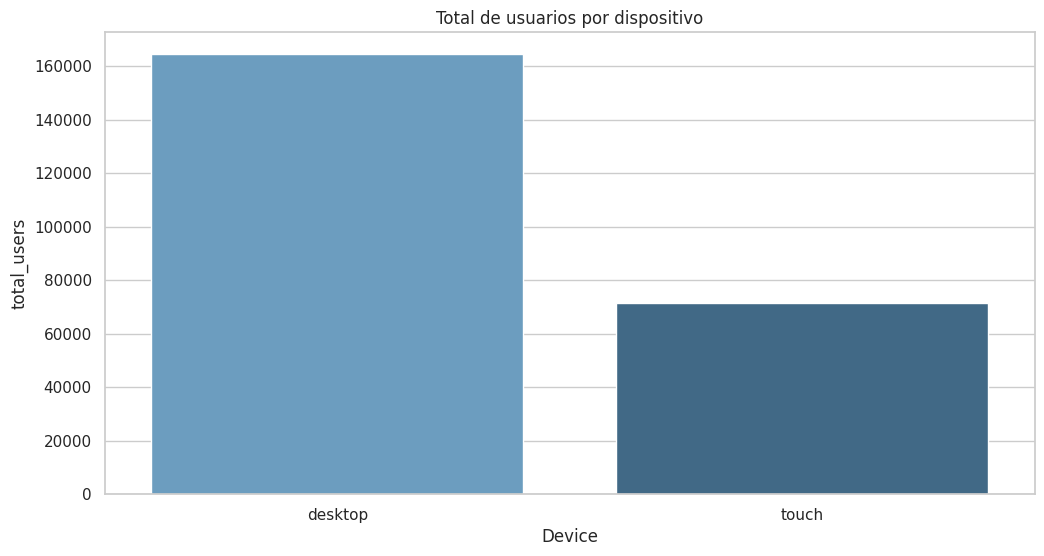

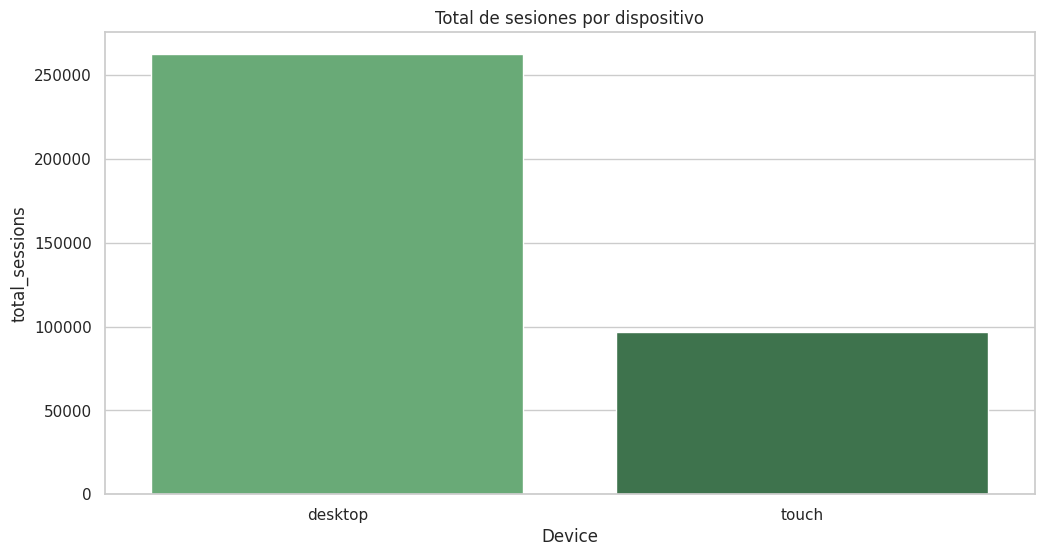

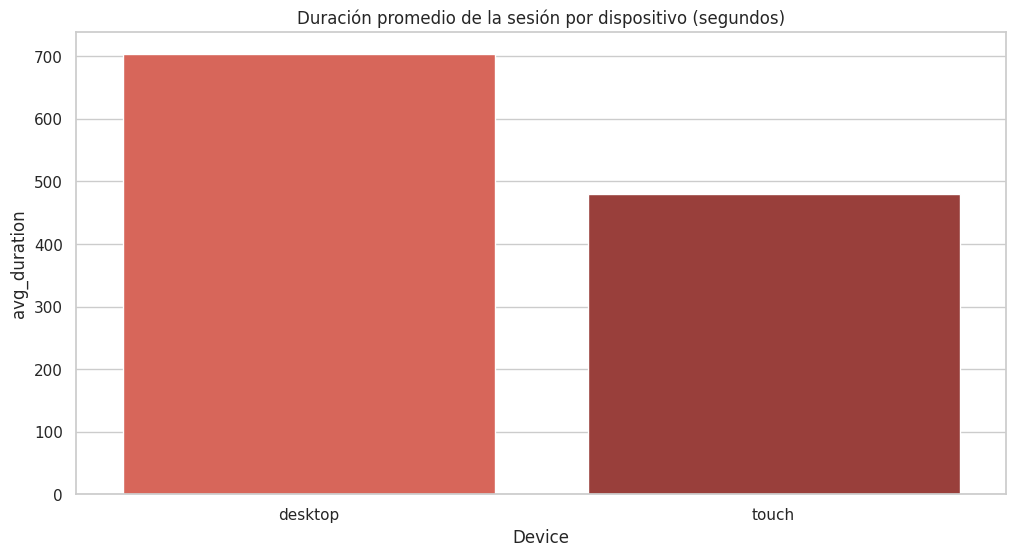

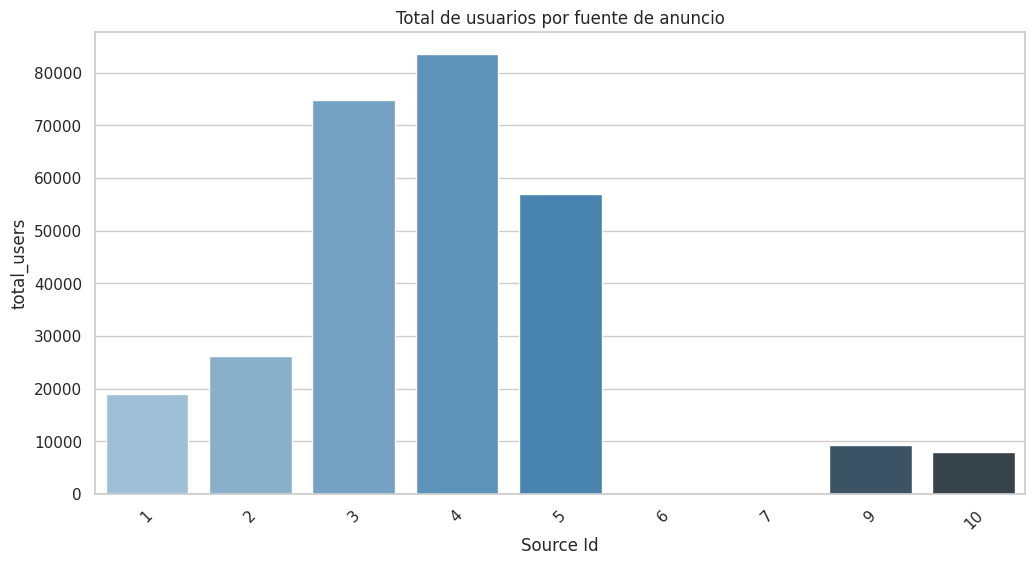

In [5]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

visits = pd.read_csv('/datasets/visits_log_us.csv')

visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits['End Ts'] = pd.to_datetime(visits['End Ts'])
visits['visit_duration_sec'] = (visits['End Ts'] - visits['Start Ts']).dt.total_seconds()

visits_device = visits.groupby('Device').agg(
    total_users=('Uid', 'nunique'),
    total_sessions=('Uid', 'count'),
    avg_duration=('visit_duration_sec', 'mean')
).reset_index()

sns.barplot(data=visits_device, x='Device', y='total_users', palette='Blues_d')
plt.title('Total de usuarios por dispositivo')
plt.show()

sns.barplot(data=visits_device, x='Device', y='total_sessions', palette='Greens_d')
plt.title('Total de sesiones por dispositivo')
plt.show()

sns.barplot(data=visits_device, x='Device', y='avg_duration', palette='Reds_d')
plt.title('Duración promedio de la sesión por dispositivo (segundos)')
plt.show()

visits_source = visits.groupby('Source Id').agg(
    total_users=('Uid', 'nunique'),
    total_sessions=('Uid', 'count'),
    avg_duration=('visit_duration_sec', 'mean')
).reset_index()

sns.barplot(data=visits_source, x='Source Id', y='total_users', palette='Blues_d')
plt.title('Total de usuarios por fuente de anuncio')
plt.xticks(rotation=45)
plt.show()


In [ ]:
El objetivo es evaluar el rendimiento de distintos dispositivos y fuentes de adquisición en términos de:
cantidad de usuarios,
número de sesiones,
duración promedio de las visitas.

    Esto ayuda a identificar qué canales y dispositivos generan mayor tráfico y engagement en el sitio web.
Preparación de los datos
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits['End Ts'] = pd.to_datetime(visits['End Ts'])
visits['visit_duration_sec'] = (visits['End Ts'] - visits['Start Ts']).dt.total_seconds()

Convierte las columnas de tiempo en formato datetime.
Calcula la duración de cada sesión en segundos.
Los datos quedan listos para medir engagement (duración) y actividad (número de sesiones) de los usuarios por diferentes variables (dispositivo o fuente).

Análisis por dispositivo
visits_device = visits.groupby('Device').agg(...)

Se generan tres métricas clave por tipo de dispositivo:
total_users: número de usuarios únicos.
total_sessions: número total de visitas.
avg_duration: duración promedio de las sesiones.

    Luego se visualiza cada métrica con gráficos de barras.
Total de usuarios por dispositivo:
Muestra qué plataforma (móvil, desktop, tablet) tiene más usuarios.
Si el móvil domina, la mayoría del tráfico llega desde smartphones.
Si desktop lidera, el sitio se usa más desde computadoras, posiblemente por tareas más detalladas o compras.

    Total de sesiones por dispositivo:
Indica la frecuencia de uso.
Si un dispositivo tiene muchas más sesiones que usuarios, significa mayor recurrencia.

    Duración promedio por dispositivo:
Refleja la calidad de la experiencia.
Duraciones más altas = usuarios más comprometidos.
Duraciones más bajas pueden señalar problemas de usabilidad o carga lenta en ese dispositivo.

Permite detectar qué dispositivo ofrece mejor rendimiento y engagement.
Por ejemplo:
Si los usuarios de desktop tienen sesiones más largas, pero el tráfico móvil es mayor, se recomienda optimizar la experiencia móvil para aumentar la retención.

    Análisis por fuente de adquisición
visits_source = visits.groupby('Source Id').agg(...)

Genera las mismas métricas (usuarios, sesiones, duración) pero agrupadas por canal de marketing o fuente publicitaria.

    El gráfico final:
sns.barplot(data=visits_source, x='Source Id', y='total_users')
muestra qué fuentes atraen más usuarios únicos.
Las fuentes con más usuarios aportan volumen de tráfico.
Las que tienen alta duración promedio probablemente atraen usuarios más calificados o interesados.
Si una fuente tiene muchos usuarios pero baja duración, podría indicar tráfico poco comprometido o campañas poco segmentadas.

    Este análisis permite comparar la efectividad y calidad del tráfico por fuente.
Es clave para decidir dónde invertir más presupuesto publicitario.

El código analiza con precisión cómo se comportan los usuarios según el dispositivo y la fuente de adquisición, permitiendo identificar las combinaciones más rentables y de mayor engagement.
Resumen:

Métrica	Por dispositivo	Por fuente
Usuarios únicos	Qué plataforma tiene más alcance	Qué canal atrae más usuarios
Sesiones totales	Qué dispositivo se usa más frecuentemente	Qué fuente genera más visitas
Duración promedio	Qué experiencia es más atractiva	Qué canal trae usuarios más interesados

Recomendaciones estratégicas:
Optimizar el canal con mayor tráfico pero menor duración (posible problema de UX).
Invertir más en las fuentes con mayor engagement y conversiones potenciales.
Si hay grandes diferencias entre dispositivos, analizar el diseño responsive o la velocidad de carga.
Combinar estos resultados con métricas de conversión o revenue para obtener una visión completa del ROI.

<div class="alert alert-block alert-warning">
<b>Comentario general (3ra Iteracion)</b> <a class=“tocSkip”></a>

Buen trabajo redactando el análisis de los resultados en cada sección.

Siempre este tipo de análisis que son un poco más complejos hay que buscar cómo explicarlos de manera sencilla considerando la audiencia a la cual se va a presentar los resultados y es ahí donde las visualizaciones juegan un papel muy importante ya que con una visualización es mucho más fácil entender la explicación que con solo valores numéricos.

No olvides revisar la parte del uso de diferentes tipos de celda para una correcta presentación de tus notebooks.

Saludos!
</div>